In [9]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\indun\Downloads\Bike_Rental_data.xlsx")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,0.992410,2011-01-01 00:00:00,springer,2011,1,-0.009452,No,5.990616,No work,Clear,0.24,0.2879,0.81,0,3,13,15.999019
1,2.004157,2011-01-01 00:00:00,springer,2011,1,1.007925,No,5.996162,No work,Clear,0.22,0.2727,0.8,0,8,32,40.004970
2,2.984610,2011-01-01 00:00:00,springer,2011,1,1.993083,No,6.004768,No work,Clear,0.22,0.2727,?,0,5,27,32.004786
3,3.993251,2011-01-01 00:00:00,springer,2011,1,2.991451,No,5.980473,No work,Clear,0.24,0.2879,0.75,0,3,10,12.999856
4,4.990763,2011-01-01 00:00:00,springer,2011,1,4.024688,No,5.984412,No work,Clear,0.24,0.2879,0.75,0,0,1,1.002089


In [3]:
df.info()
df.describe(include="all")
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100576 entries, 0 to 100575
Data columns (total 17 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   instant     100576 non-null  float64
 1   dteday      100576 non-null  object 
 2   season      100576 non-null  object 
 3   yr          100576 non-null  object 
 4   mnth        100576 non-null  object 
 5   hr          100576 non-null  float64
 6   holiday     100576 non-null  object 
 7   weekday     100576 non-null  float64
 8   workingday  100576 non-null  object 
 9   weathersit  100576 non-null  object 
 10  temp        100576 non-null  object 
 11  atemp       100576 non-null  object 
 12  hum         100576 non-null  object 
 13  windspeed   100576 non-null  object 
 14  casual      100576 non-null  object 
 15  registered  100576 non-null  object 
 16  cnt         100576 non-null  float64
dtypes: float64(4), object(13)
memory usage: 13.0+ MB


(100576, 17)

In [4]:
df.isnull().sum
# Fixing  decimal errors in integer columns
import pandas as pd
int_cols=["hr","weekday","casual","registered","cnt"]
for col in int_cols:
    df[col]=pd.to_numeric(df[col],errors="coerce")
for col in int_cols:
    df[col]=df[col].round().astype("Int64")

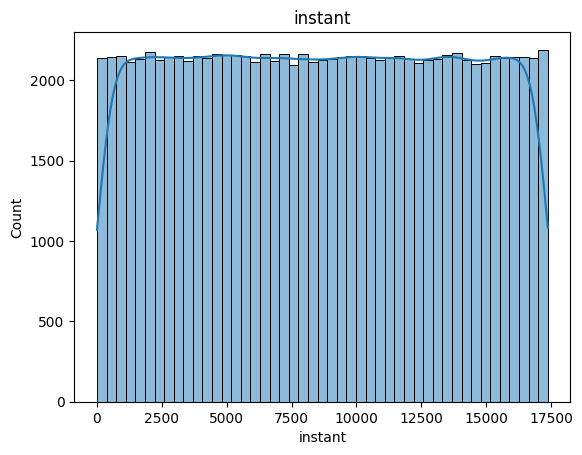

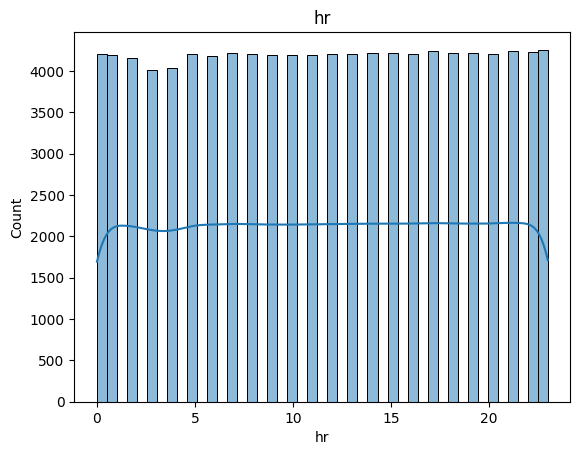

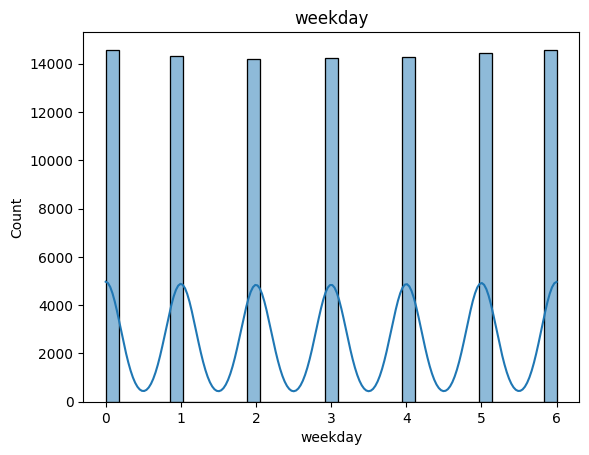

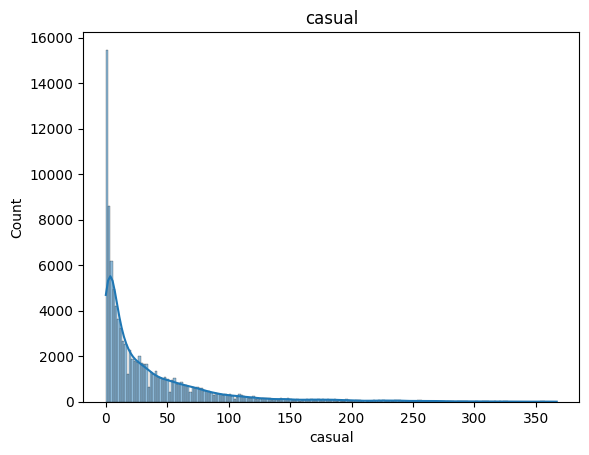

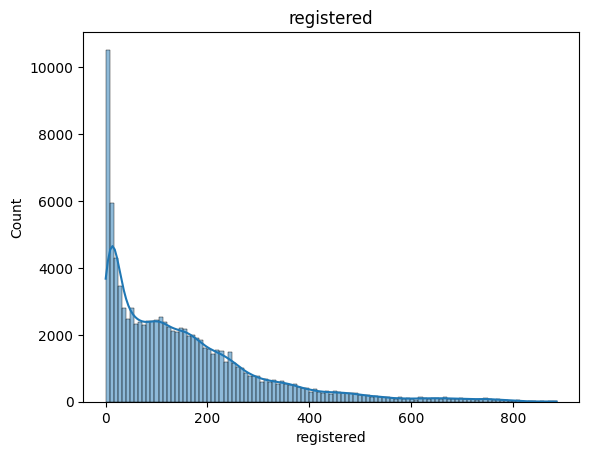

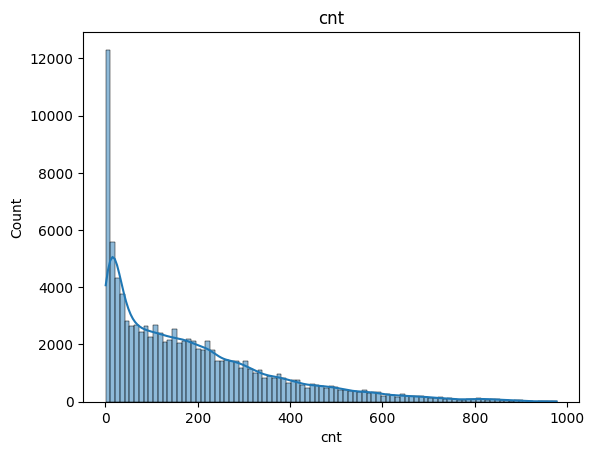

In [5]:
## Distribution of numerical and categorical data
import seaborn as sns
import matplotlib.pyplot as plt
#Numerical distribution
num_cols=df.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()

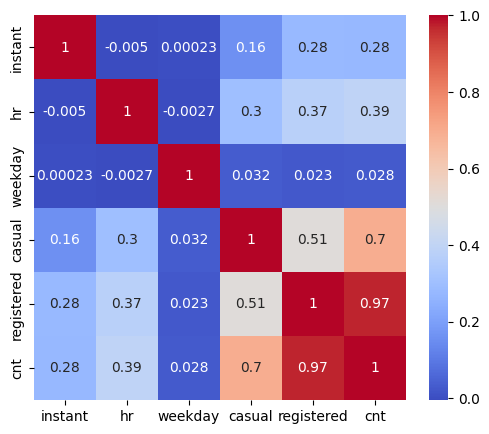

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(),annot=True,cmap="coolwarm")
plt.show()

In [7]:
## Hypothesis Testing
from scipy.stats import ttest_ind
#Seperate bike counts based on working day
working_day=df[df["workingday"]=="Working Day"]["cnt"]
non_working_day=df[df["workingday"]=="No work"]["cnt"]
t_stat,p_value=ttest_ind(working_day,non_working_day,equal_var=False)
t_stat,p_value

(np.float64(9.8064205698555), np.float64(1.0946146864072213e-22))

insight:The independent t-test shows a statistically significant difference in bike rental counts between working days and non-working days (p < 0.05). Therefore, we reject the null hypothesis and conclude that working days have a significantly different (higher) number of bike rentals compared to non-working days.

In [28]:
## one hot encoding
df_encoded=pd.get_dummies(df,drop_first=True)
X=df_encoded.iloc[:,:-1].values
Y=df_encoded.iloc[:,-1].values

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(df_encoded.drop("cnt",axis=1))
Y=df_encoded["cnt"]

In [ ]:
## splitting the data

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
lr=LinearRegression()
lr.fit(X_train, y_train)
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)
import numpy as np
from sklearn.linear_model import LassoCV
alphas=np.arange(0.01,10,0.05)
lasso=LassoCV(alphas=alphas,cv=5)
lasso.fit(X_train,y_train)
lasso.alpha_

## Linear Regression

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


TypeError: float() argument must be a string or a real number, not 'NAType'

In [32]:
df_encoded.isna().sum()


instant             0
hr                  0
weekday             0
casual              7
registered          7
                   ..
windspeed_0.7761    0
windspeed_0.806     0
windspeed_0.8358    0
windspeed_0.8507    0
windspeed_?         0
Length: 996, dtype: int64

In [33]:
df_encoded = df_encoded.dropna()


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

scaler = StandardScaler()
X = scaler.fit_transform(df_encoded.drop("cnt", axis=1))
y = df_encoded["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2: 1.0
MSE: 2.0349651883049562e-25
MAE: 3.490307156130033e-13


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2_score(y_test, y_pred)

1.0

In [36]:
from sklearn.linear_model import LassoCV

alphas = np.arange(0.01, 10, 0.05)
lasso = LassoCV(alphas=alphas, cv=5)
lasso.fit(X_train, y_train)

lasso.alpha_

np.float64(0.01)

In [37]:

for model, name in [(lasso, "Lasso"), (ridge, "Ridge")]:
    y_pred = model.predict(X_test)
    print(name)
    print("R2:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("-"*30)

Lasso
R2: 0.9999996998950003
MSE: 0.009981083025827571
RMSE: 0.09990537035528957
MAE: 0.08062277259986965
------------------------------


NotFittedError: This RidgeCV instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.